# Multi Earthkit package workflow

In this notebook you will see:
- How to download ERA5 data from the CDS using `earthkit.data`
- How to compute the specific and relative humidity using `earthkit.meteo`
- How to access spatial polygons with `earthkit.geo`
- How to compute spatial and temporal aggregations with `earthkit.transforms`
- How to plot the various output produced with `earthkit.plots`

## Components of earthkit

This tutorial uses the following earthkit components - click any logo to open the package documentation:

<div align="center">
  <br>
  <a href="https://earthkit-data.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-data-light.svg" alt="earthkit-data" width="200">
  </a>
  <a href="https://earthkit-meteo.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-meteo-light.svg" alt="earthkit-meteo" width="200">
  </a>
  <a href="https://earthkit-geo.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-geo-light.svg" alt="earthkit-geo" width="200">
  </a>
</div>
<div align="center">
  <a href="https://earthkit-transforms.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-transforms-light.svg" alt="earthkit-transforms" width="200">
  </a>
  <a href="https://earthkit-plots.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-plots-light.svg" alt="earthkit-plots" width="200">
  </a>
</div>

## 1. Getting the data

Get the ERA5 single levels data from the CDS using `earthkit.data`. We download a range of variables which are typically required for running land surface models, for example [ECland](https://github.com/ecmwf-ifs/ecland).

The source data is GRIB format, `earthkit.data` allows you to open this as an xarray object with a simple API which can handle many complex GRIB representations.

`earthkit.data` facilitates accessing data from a range of sources, we encourage you to discover all it has to offer in [earthkit.data documentation pages](https://earthkit-data.readthedocs.io/en/latest/).

In [1]:
import earthkit.data as ekd

dataset = "reanalysis-era5-single-levels"
request = {
    "product_type": "reanalysis",
    "variable": [
        "2m_dewpoint_temperature",
        "2m_temperature",
        "surface_net_solar_radiation",
        "surface_net_thermal_radiation",
        "10m_u_component_of_wind",
        "10m_v_component_of_wind",
        "surface_pressure",
        "total_precipitation"
    ],
    "year": "2020",
    "month": "01",
    "day": [f"{i:02d}" for i in range(1, 32)],
    "time": [f"{i:02d}:00" for i in range(24)],
    "area": [65, -10, 45, 5],  # North, West, South, East
}

# Use earthkit data to submit the above request to the CDS
data = ekd.from_source("cds", dataset, request)
era5_ds = data.to_xarray(time_dims=["valid_time"])
era5_ds

<xarray.Dataset> Size: 235MB
Dimensions:     (valid_time: 744, latitude: 81, longitude: 61)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:...
  * latitude    (latitude) float64 648B 65.0 64.75 64.5 ... 45.5 45.25 45.0
  * longitude   (longitude) float64 488B -10.0 -9.75 -9.5 -9.25 ... 4.5 4.75 5.0
Data variables:
    10u         (valid_time, latitude, longitude) float64 29MB ...
    10v         (valid_time, latitude, longitude) float64 29MB ...
    2d          (valid_time, latitude, longitude) float64 29MB ...
    2t          (valid_time, latitude, longitude) float64 29MB ...
    sp          (valid_time, latitude, longitude) float64 29MB ...
    ssr         (valid_time, latitude, longitude) float64 29MB ...
    str         (valid_time, latitude, longitude) float64 29MB ...
    tp          (valid_time, latitude, longitude) float64 29MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

## 2. Compute specific and relative humidity

Below we compute the specific humidity from the dew point temperature and pressure using the [specific_humidity_from_dewpoint](https://earthkit-meteo.readthedocs.io/en/latest/autoapi/earthkit/meteo/thermo/specific_humidity_from_dewpoint.html) function in `earthkit.meteo.thermo`

In [2]:
from earthkit.meteo import thermo

sh_da = thermo.specific_humidity_from_dewpoint(era5_ds["2d"], era5_ds["sp"])
# Update some metadata fields:
sh_da.attrs["standard_name"] = "specific_humidity"
sh_da.attrs["long_name"] = "Specific humidity near the surface"
sh_da = sh_da.rename("q2m")
sh_da.attrs["units"] = "kg kg^-1"
# Add to our existing dataset:
era5_ds["2q"] = sh_da

Similarly, below demonstrates how to compute the relative humidity from the air temperature and dew-point temperature using the [relative_humidity_from_dewpoint](https://earthkit-meteo.readthedocs.io/en/latest/autoapi/earthkit/meteo/thermo/relative_humidity_from_dewpoint.html) function in `earthkit.meteo.thermo`.

In [3]:
rh_da = thermo.relative_humidity_from_dewpoint(
    era5_ds["2t"], era5_ds["2d"]
)
# Update some metadata fields:
rh_da.attrs["standard_name"] = "relative_humidity"
rh_da.attrs["long_name"] = "Relative humidity near the surface"
rh_da.attrs["units"] = "%"
rh_da = rh_da.rename("r2m")
# Add to our existing dataset:
era5_ds["2r"] = rh_da

era5_ds

<xarray.Dataset> Size: 294MB
Dimensions:     (valid_time: 744, latitude: 81, longitude: 61)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:...
  * latitude    (latitude) float64 648B 65.0 64.75 64.5 ... 45.5 45.25 45.0
  * longitude   (longitude) float64 488B -10.0 -9.75 -9.5 -9.25 ... 4.5 4.75 5.0
Data variables:
    10u         (valid_time, latitude, longitude) float64 29MB ...
    10v         (valid_time, latitude, longitude) float64 29MB ...
    2d          (valid_time, latitude, longitude) float64 29MB 279.2 ... 279.7
    2t          (valid_time, latitude, longitude) float64 29MB 280.6 ... 280.4
    sp          (valid_time, latitude, longitude) float64 29MB 9.927e+04 ... ...
    ssr         (valid_time, latitude, longitude) float64 29MB ...
    str         (valid_time, latitude, longitude) float64 29MB ...
    tp          (valid_time, latitude, longitude) float64 29MB ...
    2q          (valid_time, latitude, longitude) float64 29MB 0.005908 ... 0...
    2r          (valid_time, latitude, longitude) float64 29MB 90.77 ... 95.31
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

The output above shows the addition of the two humidity variables (`2q` and `2r`) in the original `xarray.Dataset`.

## 3. Calculate the monthly mean of daily maximum

We can use [earthkit.transforms](https://earthkit-transforms.readthedocs.io/en/latest/)
to calculate monthly and daily statistics of the variables in the dataset.

We will calculate the monthly mean of the daily maximum of all the variables.
As we have a single month of data, this will reduce to a single time step,
very convenient for our subsequent plotting.
Note that this calculation may not be useful for all the variables in our dataset,
we just demonstrate the simplicity of performing the calculations in batch.

In [4]:
from earthkit import transforms as ekt

era5_ds_daily_max = ekt.temporal.daily_max(era5_ds)
era5_ds_monthly_mean_daily_max = ekt.temporal.monthly_mean(era5_ds_daily_max)
era5_ds_monthly_mean_daily_max

<xarray.Dataset> Size: 396kB
Dimensions:     (valid_time: 1, latitude: 81, longitude: 61)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8B 2020-01-01
  * latitude    (latitude) float64 648B 65.0 64.75 64.5 ... 45.5 45.25 45.0
  * longitude   (longitude) float64 488B -10.0 -9.75 -9.5 -9.25 ... 4.5 4.75 5.0
Data variables:
    10u         (valid_time, latitude, longitude) float64 40kB 10.63 ... 0.6168
    10v         (valid_time, latitude, longitude) float64 40kB 8.817 ... 1.676
    2d          (valid_time, latitude, longitude) float64 40kB 275.7 ... 277.6
    2t          (valid_time, latitude, longitude) float64 40kB 278.1 ... 282.7
    sp          (valid_time, latitude, longitude) float64 40kB 9.938e+04 ... ...
    ssr         (valid_time, latitude, longitude) float64 40kB 1.051e+05 ... ...
    str         (valid_time, latitude, longitude) float64 40kB -8.65e+04 ... ...
    tp          (valid_time, latitude, longitude) float64 40kB 0.0007672 ... ...
    2q          (valid_time, latitude, longitude) float64 40kB 0.004708 ... 0...
    2r          (valid_time, latitude, longitude) float64 40kB 89.3 ... 92.94
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

## 4. Plot the gridded data

Below we use [earthkit.plots](https://earthkit-plots.readthedocs.io/en/latest/) to visualise the output. `earthkit.plots` simplifies much of fiddley bits when creating publication quality figures.

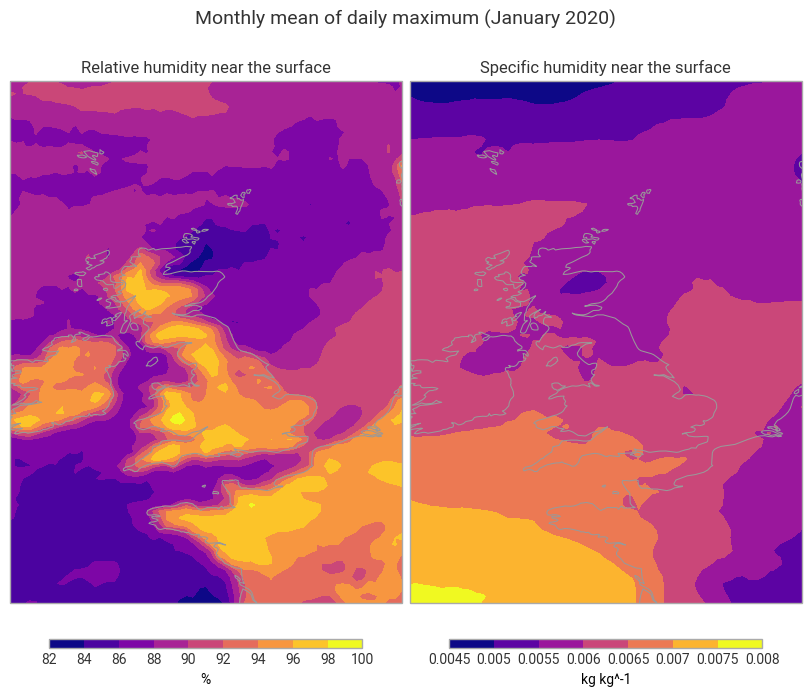

In [5]:
import earthkit.plots as ekp

figure = ekp.Figure(rows=1, columns=2)

subplot = figure.add_map()
subplot.contourf(era5_ds_monthly_mean_daily_max["2r"])
subplot.title("{long_name}")
subplot.legend(label="%")

subplot = figure.add_map()
subplot.contourf(era5_ds_monthly_mean_daily_max["2q"])
subplot.title("{long_name}")
subplot.legend(label="kg kg^-1")

figure.coastlines(color="#999999")

figure.title("Monthly mean of daily maximum ({valid_time:%B %Y})")

figure.show()

## 5. Computing the regional aggregations

earthkit.geo provides a range of spatial features which can be used to aggregate data over. The example below fetches the [Nomenclature of territorial units for statistics (NUTS)](https://ec.europa.eu/eurostat/web/nuts) level 1 regions for the UK. We choose the NUTS year 2021 as the UK is not included in the NUTS database after this. For more details see the [earthkit.geo.gisco API reference guide](https://earthkit-geo.readthedocs.io/en/latest/autoapi/earthkit/geo/gisco/index.html).

In [6]:
from earthkit import geo as ekg

nuts_l1 = ekg.gisco.nuts_regions(level=1, year=2021).to_geopandas()
nuts_l1_uk = nuts_l1[nuts_l1["CNTR_CODE"] == "UK"]
nuts_l1_uk

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,NAME_ENGL,NAME_FREN,ISO3_CODE,SVRG_UN,CAPT,EU_STAT,EFTA_STAT,CC_STAT,NAME_GERM,geometry
64,UKK,1,UK,South West (England),South West (England),0,0,0,United Kingdom,Royaume-Uni,GBR,UN Member State,London,F,F,F,Vereinigtes Königreich,"MULTIPOLYGON (((-1.67314 52.0363, -1.66573 51...."
65,UKL,1,UK,Wales,Wales,0,0,0,United Kingdom,Royaume-Uni,GBR,UN Member State,London,F,F,F,Vereinigtes Königreich,"MULTIPOLYGON (((-3.36339 53.35203, -3.16975 53..."
66,UKN,1,UK,Northern Ireland,Northern Ireland,0,0,0,United Kingdom,Royaume-Uni,GBR,UN Member State,London,F,F,F,Vereinigtes Königreich,"MULTIPOLYGON (((-6.09652 55.20602, -6.03339 55..."
79,UKC,1,UK,North East (England),North East (England),0,0,0,United Kingdom,Royaume-Uni,GBR,UN Member State,London,F,F,F,Vereinigtes Königreich,"POLYGON ((-1.34737 54.86069, -1.24223 54.72259..."
80,UKD,1,UK,North West (England),North West (England),0,0,0,United Kingdom,Royaume-Uni,GBR,UN Member State,London,F,F,F,Vereinigtes Königreich,"POLYGON ((-2.59587 54.96483, -2.56833 54.92683..."
81,UKE,1,UK,Yorkshire and the Humber,Yorkshire and the Humber,0,0,0,United Kingdom,Royaume-Uni,GBR,UN Member State,London,F,F,F,Vereinigtes Königreich,"POLYGON ((-0.79091 54.55948, -0.54857 54.45762..."
93,UKF,1,UK,East Midlands (England),East Midlands (England),0,0,0,United Kingdom,Royaume-Uni,GBR,UN Member State,London,F,F,F,Vereinigtes Königreich,"POLYGON ((-0.20717 53.49469, -0.12155 53.44174..."
94,UKG,1,UK,West Midlands (England),West Midlands (England),0,0,0,United Kingdom,Royaume-Uni,GBR,UN Member State,London,F,F,F,Vereinigtes Königreich,"POLYGON ((-1.7716 53.0218, -1.8306 52.95586, -..."
95,UKH,1,UK,East of England,East of England,0,0,0,United Kingdom,Royaume-Uni,GBR,UN Member State,London,F,F,F,Vereinigtes Königreich,"POLYGON ((1.67548 52.74269, 1.73639 52.64175, ..."
96,UKI,1,UK,London,London,0,0,0,United Kingdom,Royaume-Uni,GBR,UN Member State,London,F,F,F,Vereinigtes Königreich,"POLYGON ((-0.19819 51.46752, -0.21534 51.47063..."


We can now combine the geopandas data frame with our gridded data and compute the regional mean of the monthly mean daily maximum data

In [7]:
era5_ds_mm_dm_region_aggregated = ekt.spatial.reduce(
    era5_ds_monthly_mean_daily_max, nuts_l1_uk, how="mean", 
    weights="latitude",  # Weight the mean with latitude
)
era5_ds_mm_dm_region_aggregated

<xarray.Dataset> Size: 1kB
Dimensions:     (index: 12)
Coordinates:
  * index       (index) int64 96B 64 65 66 79 80 81 93 94 95 96 97 106
    valid_time  datetime64[ns] 8B 2020-01-01
Data variables:
    10u         (index) float64 96B 4.602 4.826 4.966 ... 4.238 4.643 6.243
    10v         (index) float64 96B 5.04 5.011 5.608 5.103 ... 4.752 5.069 6.271
    2d          (index) float64 96B 280.7 280.1 279.2 ... 280.3 280.4 278.6
    2t          (index) float64 96B 282.4 281.6 281.3 ... 282.2 282.2 280.6
    sp          (index) float64 96B 1.012e+05 9.993e+04 ... 1.015e+05 9.87e+04
    ssr         (index) float64 96B 4.995e+05 4.476e+05 ... 5.548e+05 2.841e+05
    str         (index) float64 96B -5.093e+04 -4.346e+04 ... -4.824e+04
    tp          (index) float64 96B 0.0006753 0.0008545 ... 0.0005381 0.0008527
    2q          (index) float64 96B 0.00659 0.006373 ... 0.006435 0.005811
    2r          (index) float64 96B 95.44 95.33 92.88 ... 95.09 95.22 92.12
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

We can now plot this for the regions using the [earthkit.plots.geo.choropleth](https://earthkit-plots.readthedocs.io/en/latest/examples/examples/misc/choropleth.html) function.

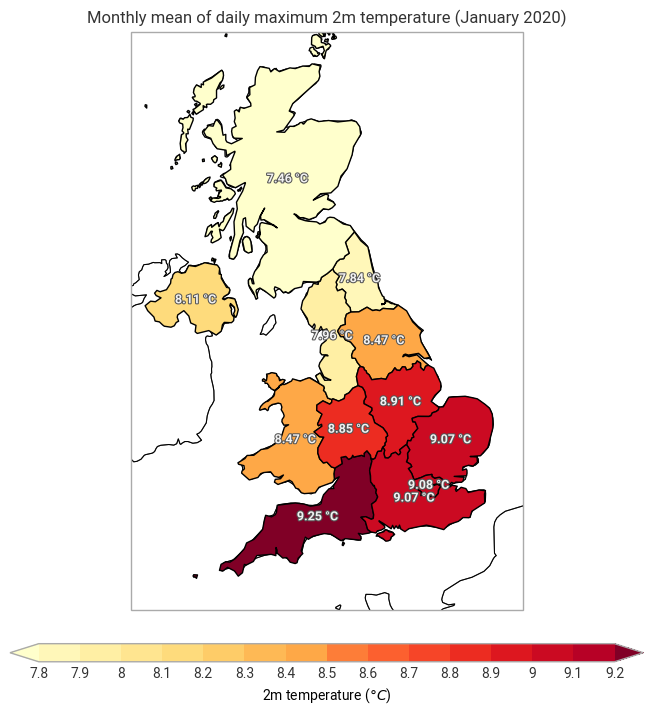

In [8]:
# Add the reduced data back to the original GeoDataFrame for plotting
nuts_l1_uk = nuts_l1_uk.assign(t2m=era5_ds_mm_dm_region_aggregated['2t'])
t_style = ekp.styles.Style(
    cmap="YlOrRd", levels=[7.8+(i/10) for i in range(15)], extend="both",
    units="celsius", edgecolor="black",
)
choropleth = ekp.geo.choropleth(
    nuts_l1_uk,
    z="t2m",
    domain="UK",
    metadata={"units": "K", "long_name": "2m temperature"},
    labels="{t2m:0.2f} °C",
    style=t_style,
)
choropleth.coastlines(color="black")
choropleth.title("Monthly mean of daily maximum 2m temperature (January 2020)")
choropleth.show()